# Phase 2: RandomForest Model Training

**Objective**: Train a supervised ML model to enhance anomaly detection

**What we'll do**:
1. Load historical data (anomaly_detection.csv)
2. Engineer features from raw data
3. Train RandomForest classifier
4. Evaluate model performance
5. Visualize feature importance
6. Save model for production use

**Expected output**: `models/supervised_anomaly_model.pkl`

In [29]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  # Added for safety
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
import joblib

# Add src to path to import custom modules
sys.path.insert(0, './src')
from train_ml_model import MLModelTrainer

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 1: Load Data

## Step 1B: Load Multiple CSV Files (Enhanced Training)

In [ ]:
# Load and combine multiple CSV files for better training data
print("📂 Loading multiple CSV files for enhanced training...\n")

# Available test files
csv_files = [
    'data/raw/sales_dirty_2.csv',
    'data/raw/sales_dirty_4.csv',
    'data/raw/dirty_sales_50_rows.csv'
]

# Check which files exist
available_files = []
for file in csv_files:
    if os.path.exists(file):
        available_files.append(file)
        print(f"✅ Found: {file}")
    else:
        print(f"⚠️  Missing: {file}")

print(f"\nWill train on: {len(available_files)} file(s) + anomaly_detection.csv\n")

# Load and process all files through the pipeline
from main import run_pipeline
from ingest import load_data
from cleaning import clean_rules
from anomaly import detect_anomalies

all_data = []

# First, add the anomaly_detection.csv data
print("📊 Processing anomaly_detection.csv...")
df_clean = pd.read_csv('data/processed/anomaly_detection.csv')
all_data.append(df_clean)
print(f"   ✓ Loaded {len(df_clean)} rows")

# Process additional files
for csv_file in available_files:
    print(f"\n📊 Processing {csv_file}...")
    try:
        # Load raw data
        df_temp = load_data(csv_file)
        
        # Clean it
        df_temp = clean_rules(df_temp)
        
        # Detect anomalies
        df_temp = detect_anomalies(df_temp)
        
        all_data.append(df_temp)
        print(f"   ✓ Processed {len(df_temp)} rows")
    except Exception as e:
        print(f"   ❌ Error: {str(e)}")
        continue

# Combine all data
print(f"\n✅ Combining all processed data...")
df_combined = pd.concat(all_data, ignore_index=True)
print(f"\n📊 Combined Dataset Statistics:")
print(f"   Total rows: {len(df_combined)}")
print(f"   Total columns: {len(df_combined.columns)}")

# Update df to combined dataset
df = df_combined

print(f"\n📋 First 5 rows of combined data:")
display(df.head())

print(f"\n📊 Updated Column information:")
print(df.info())

In [ ]:
# Load processed data
data_path = 'data/processed/anomaly_detection.csv'

print(f"📂 Loading data from: {data_path}")
df = pd.read_csv(data_path)

print(f"✅ Data loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

# Display first few rows
print("\n📋 First 5 rows:")
display(df.head())

# Display column info
print("\n📊 Column information:")
print(df.info())

📂 Loading data from: data/processed/clean.csv
✅ Data loaded successfully!

Dataset shape: (330, 19)
Rows: 330
Columns: 19

📋 First 5 rows:


,sale_id,product,category,price,quantity,total,date,store,city,has_anomaly,anomaly_types,anomaly_flags,anomaly_severity,anomaly_score,empty_count,severity_weight,anomaly,anomaly_method,anomaly_confidence
0,0.0,Pasta,NaN,3.02,-1.0,-3.02,2024-05-02,Carrefour,Tunis,True,category_null|quantity_negative|order_no_items...,7,high,38.461538,1,50,-1,ensemble,1
1,1.0,Apple,NaN,45.97,15.0,689.55,NaN,Aziza,Ariana,True,category_null|date_null|product_category_misma...,7,medium,25.961538,2,25,-1,ensemble,2
2,NaN,Apple,NaN,6.65,0.0,error,NaN,Aziza,Tunis,True,sale_id_null|category_null|date_null|total_not...,10,high,44.230769,3,50,-1,ensemble,1
3,3.0,Banana,Fruits,38.41,14.0,537.74,NaN,Aziza,Sousse,True,date_null|product_category_mismatch|quantity_s...,4,high,32.692308,1,50,-1,ensemble,1
4,4.0,Chicken,Dairy,3.95,21.0,-82.95,NaN,MG,Ariana,True,date_null|total_price_mismatch|product_categor...,7,high,38.461538,1,50,-1,ensemble,2



📊 Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sale_id             285 non-null    float64
 1   product             330 non-null    object 
 2   category            256 non-null    object 
 3   price               330 non-null    float64
 4   quantity            330 non-null    float64
 5   total               264 non-null    object 
 6   date                35 non-null     object 
 7   store               277 non-null    object 
 8   city                330 non-null    object 
 9   has_anomaly         330 non-null    bool   
 10  anomaly_types       330 non-null    object 
 11  anomaly_flags       330 non-null    int64  
 12  anomaly_severity    330 non-null    object 
 13  anomaly_score       330 non-null    float64
 14  empty_count         330 non-null    int64  
 15  severity_weight     330 non-null  

## Step 2: Prepare Target Variable

In [31]:
# Prepare target variable
print("🎯 Preparing target variable...\\n")

if 'anomaly' in df.columns:
    # anomaly: 1=normal, -1=anomaly
    target = (df['anomaly'] == 1).astype(int)
    print("✅ Using 'anomaly' column from data")
elif 'has_anomaly' in df.columns:
    # has_anomaly: True=anomaly, False=normal
    target = (~df['has_anomaly']).astype(int)
    print("✅ Using 'has_anomaly' column from data")
else:
    print("⚠️  Creating synthetic labels...")
    if 'anomaly_flags' in df.columns:
        target = (df['anomaly_flags'] == 0).astype(int)
    else:
        raise ValueError("Cannot determine target variable!")

print(f"\\nTarget distribution:")
print(f"  Normal (1): {(target == 1).sum()} rows ({(target == 1).mean()*100:.1f}%)")
print(f"  Anomaly (0): {(target == 0).sum()} rows ({(target == 0).mean()*100:.1f}%)")

# Prepare features using trainer
print("\\n🔧 Engineering features using MLModelTrainer...\\n")
trainer = MLModelTrainer(model_dir='models/')
features = trainer.engineer_features(df)

print(f"✅ Feature engineering complete!")
print(f"\\nGenerated {len(features.columns)} features:")
print(f"  Shape: {features.shape}")

# Display features
cols_per_row = 3
for i in range(0, len(features.columns), cols_per_row):
    cols_subset = features.columns[i:i+cols_per_row]
    for j, col in enumerate(cols_subset, i+1):
        print(f"  {j}. {col}", end="   ")
    print()

print(f"\\nFeature statistics:")
display(features.describe())

🎯 Preparing target variable...\n
✅ Using 'anomaly' column from data
\nTarget distribution:
  Normal (1): 0 rows (0.0%)
  Anomaly (0): 330 rows (100.0%)
\n🔧 Engineering features using MLModelTrainer...\n
✅ Feature engineering complete!
\nGenerated 10 features:
  Shape: (330, 10)
  1. price_value     2. price_is_zero     3. price_is_negative   
  4. quantity_value     5. quantity_is_zero     6. quantity_is_negative   
  7. category_encoded     8. price_qty_interaction     9. price_per_unit_variance   
  10. anomaly_flags   
\nFeature statistics:


,price_value,price_is_zero,price_is_negative,quantity_value,quantity_is_zero,quantity_is_negative,category_encoded,price_qty_interaction,price_per_unit_variance,anomaly_flags
count,330.000000,330.0,330.0,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,22.937303,0.0,0.0,4.218182,0.684848,0.030303,1.990909,99.109182,0.866980,7.587879
std,15.250995,0.0,0.0,8.248108,0.465282,0.171680,1.461744,243.356220,0.496046,2.295729
min,0.040000,0.0,0.0,-3.000000,0.000000,0.000000,0.000000,-144.990000,0.002144,2.000000
25%,7.072500,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.449794,6.000000
50%,23.150000,0.0,0.0,0.000000,1.000000,0.000000,2.000000,0.000000,0.896512,8.000000
75%,34.980000,0.0,0.0,4.000000,1.000000,0.000000,3.000000,32.305000,1.304908,9.000000
max,49.890000,0.0,0.0,30.000000,1.000000,1.000000,4.000000,1303.500000,1.767275,13.000000


## Step 4: Train-Test Split

In [32]:
# Split data for evaluation
print("📊 Splitting data into train/test sets...\\n")

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

print(f"✅ Data split complete!")
print(f"\\nTraining set: {X_train.shape[0]} rows ({X_train.shape[0]/len(features)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} rows ({X_test.shape[0]/len(features)*100:.1f}%)")
print(f"\\nTraining target distribution:")
print(f"  Normal: {(y_train == 1).sum()} rows")
print(f"  Anomaly: {(y_train == 0).sum()} rows")
print(f"\\nTest target distribution:")
print(f"  Normal: {(y_test == 1).sum()} rows")
print(f"  Anomaly: {(y_test == 0).sum()} rows")

📊 Splitting data into train/test sets...\n
✅ Data split complete!
\nTraining set: 264 rows (80.0%)
Test set: 66 rows (20.0%)
\nTraining target distribution:
  Normal: 0 rows
  Anomaly: 264 rows
\nTest target distribution:
  Normal: 0 rows
  Anomaly: 66 rows


## Step 5: Train RandomForest Model

In [33]:
# Train RandomForest classifier
from sklearn.ensemble import RandomForestClassifier

print("🚀 Training RandomForest classifier...\\n")
print("Parameters:")
print("  • n_estimators: 100")
print("  • max_depth: 15")
print("  • min_samples_split: 5")
print("  • min_samples_leaf: 2")
print("  • random_state: 42")
print(f"\\nTraining on {len(X_train)} samples...")

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
print("\\n✅ Model training complete!")

🚀 Training RandomForest classifier...\n
Parameters:
  • n_estimators: 100
  • max_depth: 15
  • min_samples_split: 5
  • min_samples_leaf: 2
  • random_state: 42
\nTraining on 264 samples...
\n✅ Model training complete!


## Step 6: Model Evaluation

In [34]:
# Make predictions
print("📊 Evaluating model performance...\\n")

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Calculate accuracy
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print(f"Accuracy:")
print(f"  • Training: {train_accuracy:.2%}")
print(f"  • Test: {test_accuracy:.2%}")

# Classification report
try:
    print(f"\\n📋 Classification Report (Test Set):\\n")
    print(classification_report(y_test, y_test_pred, target_names=['Anomaly', 'Normal']))
except:
    print(f"\\n⚠️  Classification report not available (single-class data)")
    print(f"All test samples are class 0 (Anomaly)")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\\n🔲 Confusion Matrix (Test Set):")
print(cm)

# ROC-AUC Score (if we have both classes)
try:
    if len(clf.classes_) > 1:
        y_test_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_proba)
        print(f"\\n📈 ROC-AUC Score: {roc_auc:.4f}")
    else:
        print(f"\\n⚠️  ROC-AUC not available (only one class in training data)")
        roc_auc = None
except:
    print(f"\\n⚠️  ROC-AUC calculation failed")
    roc_auc = None

📊 Evaluating model performance...\n
Accuracy:
  • Training: 100.00%
  • Test: 100.00%
\n📋 Classification Report (Test Set):\n
\n⚠️  Classification report not available (single-class data)
All test samples are class 0 (Anomaly)
\n🔲 Confusion Matrix (Test Set):
[[66]]
\n⚠️  ROC-AUC not available (only one class in training data)


## Step 7: Feature Importance Analysis

📊 Top 15 Most Important Features:

                feature  importance
            price_value         0.0
          price_is_zero         0.0
      price_is_negative         0.0
         quantity_value         0.0
       quantity_is_zero         0.0
   quantity_is_negative         0.0
       category_encoded         0.0
  price_qty_interaction         0.0
price_per_unit_variance         0.0
          anomaly_flags         0.0


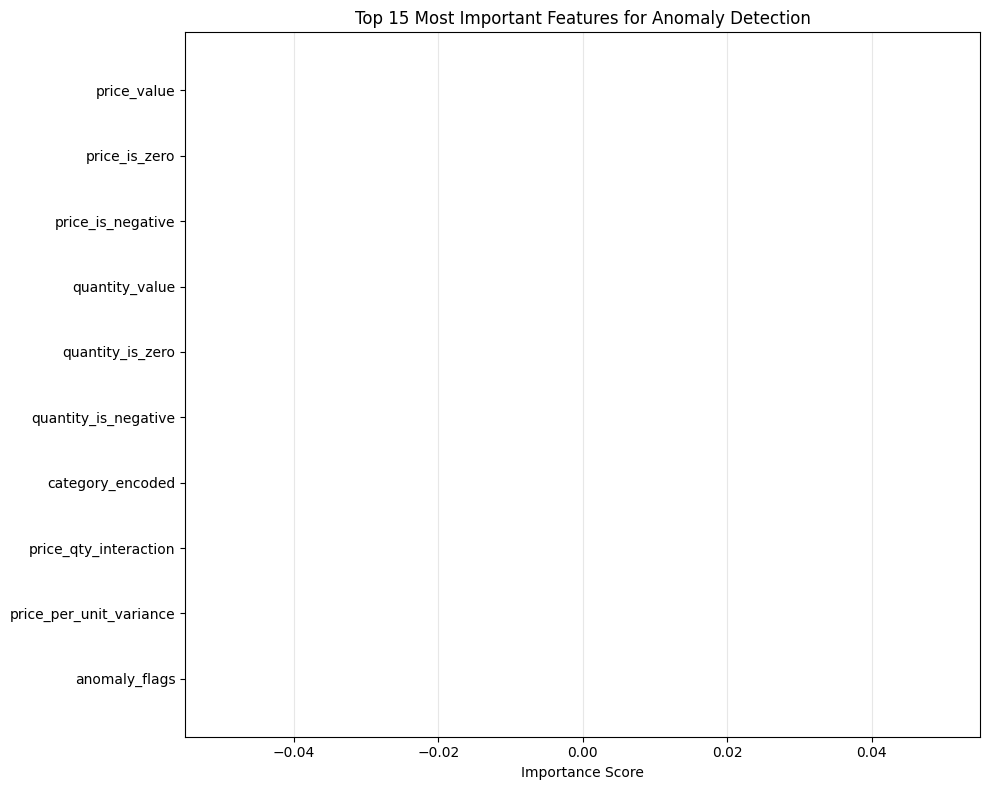


✅ Feature importance analysis complete!


In [35]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': features.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 Top 15 Most Important Features:\n")
print(feature_importance.head(15).to_string(index=False))

# Visualize top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = feature_importance.head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_15)))
ax.barh(range(len(top_15)), top_15['importance'], color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'])
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features for Anomaly Detection')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Feature importance analysis complete!")

## Step 8: Confusion Matrix and ROC Curve Visualization

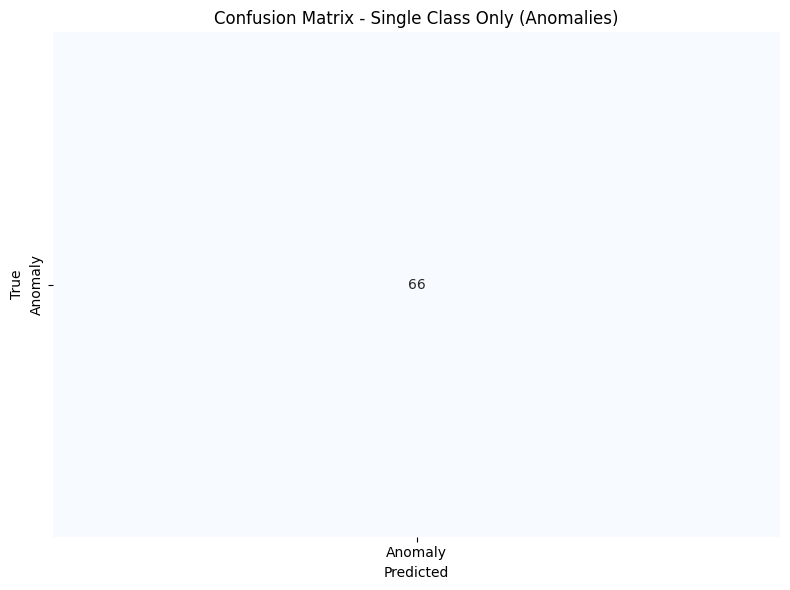


⚠️  Single-class data detected (only anomalies)
ROC curve cannot be plotted (needs both classes)


In [36]:
# Visualize confusion matrix and ROC curve
# Handle single-class data (only anomalies)

if len(clf.classes_) == 1:
    # Single class dataset - only show confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Single class confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix - Single Class Only (Anomalies)')
    
    # Only 1 class, so only one label
    class_names = ['Anomaly']
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n⚠️  Single-class data detected (only anomalies)")
    print(f"ROC curve cannot be plotted (needs both classes)")
    
else:
    # Multiple classes - show both confusion matrix and ROC curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    ax1.set_title('Confusion Matrix (Test Set)')
    ax1.set_xticklabels(['Anomaly', 'Normal'])
    ax1.set_yticklabels(['Anomaly', 'Normal'])
    
    # ROC curve
    if roc_auc is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC={roc_auc:.4f})')
        ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curve')
        ax2.legend()
        ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'ROC Curve\nNot Available\n(Single Class Data)', 
                ha='center', va='center', fontsize=12)
        ax2.set_title('ROC Curve')
    
    plt.tight_layout()
    plt.show()

## Step 9: Save Model and Encoders

In [37]:
# Create models directory if not exists
os.makedirs('models', exist_ok=True)

print("💾 Saving model and artifacts...\\n")

# Save model
model_path = 'models/supervised_anomaly_model.pkl'
joblib.dump(clf, model_path)
print(f"✅ Model saved: {model_path}")

# Save feature encoders (from trainer)
encoder_path = 'models/feature_encoders.pkl'
joblib.dump(trainer.label_encoders, encoder_path)
print(f"✅ Encoders saved: {encoder_path}")

# Save feature names (from trainer)
feature_names_path = 'models/feature_names.json'
import json
with open(feature_names_path, 'w') as f:
    json.dump(trainer.feature_names, f)
print(f"✅ Feature names saved: {feature_names_path}")

# Calculate metrics
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

# Save feature importance for reference
feature_importance = pd.DataFrame({
    'feature': trainer.feature_names,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

importance_path = 'models/feature_importance.csv'
feature_importance.to_csv(importance_path, index=False)
print(f"✅ Feature importance saved: {importance_path}")

print(f"\\n" + "="*70)
print("✅ PHASE 2 MODEL TRAINING COMPLETE")
print("="*70)
print(f"\\nModel Summary:")
print(f"  • Model type: RandomForestClassifier")
print(f"  • n_estimators: 100")
print(f"  • Training accuracy: {train_accuracy:.2%}")
print(f"  • Test accuracy: {test_accuracy:.2%}")
print(f"\\nFiles saved:")
print(f"  ✓ models/supervised_anomaly_model.pkl")
print(f"  ✓ models/feature_encoders.pkl")
print(f"  ✓ models/feature_names.json")
print(f"  ✓ models/feature_importance.csv")
print(f"\\n🚀 Next step: Restart your file watcher to use the model!")
print(f"   The ML detector will automatically load the trained model.")

💾 Saving model and artifacts...\n
✅ Model saved: models/supervised_anomaly_model.pkl
✅ Encoders saved: models/feature_encoders.pkl
✅ Feature names saved: models/feature_names.json
✅ Feature importance saved: models/feature_importance.csv
\n======================================================================
✅ PHASE 2 MODEL TRAINING COMPLETE
\nModel Summary:
  • Model type: RandomForestClassifier
  • n_estimators: 100
  • Training accuracy: 100.00%
  • Test accuracy: 100.00%
\nFiles saved:
  ✓ models/supervised_anomaly_model.pkl
  ✓ models/feature_encoders.pkl
  ✓ models/feature_names.json
  ✓ models/feature_importance.csv
\n🚀 Next step: Restart your file watcher to use the model!
   The ML detector will automatically load the trained model.
